Example traces of the closest and farthest SNN and MPR outputs.  

In [14]:
# Import necessary packages
# %matplotlib inline
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import pickle
import zipfile
import seaborn as sns
from pathlib import Path

import Figures.plotting_style as ps
ps.figure_style()
colors, dpi = ps.figure_style()

In [15]:
### Compute Power Spectrum using Fourier Analysis

def fourier_analysis(signal, dt, t_end):

    time_lowerbound =  t_end-1000 ; time_upperbound = t_end
    ttt = dt / 1000  #0.01ms is time resolution for signal
    
    signal = np.array(signal)[int(time_lowerbound/dt):int(time_upperbound/dt)]
    FFT_singal = np.fft.fft(signal)
    power_spectrum= np.abs(FFT_singal)**2
    freqq = np.fft.fftfreq(power_spectrum.size , d=ttt)
    positive_freq_indices = freqq > 0
    frequencies = freqq[positive_freq_indices]
    power_spectrum = power_spectrum[positive_freq_indices]

    power_spectrum = power_spectrum / np.max(power_spectrum)
    return frequencies, power_spectrum

In [56]:
# 6Hz examples

# closest parameter set file
parameter_set_name = 'FIGUREDATA/optimized_frequencies'
param_fit_index_closest_6hz = 6 #

mpr_filename_closest_6hz = parameter_set_name + str(param_fit_index_closest_6hz) + '_MPR.pkl'  # Exact path inside the zip
snn_filename_closest_6hz = parameter_set_name + str(param_fit_index_closest_6hz) + '_SNN_Variation_VR_85_VT_85.pkl' # Exact path inside the zip


# farthest parameter set file
parameter_set_name = 'FIGUREDATA/rand_init_optimization_results'
param_fit_index_farthest_6hz = 24 

mpr_filename_farthest_6hz = parameter_set_name + str(param_fit_index_farthest_6hz) + '_MPR.pkl'  # Exact path inside the zip
snn_filename_farthest_6hz = parameter_set_name + str(param_fit_index_farthest_6hz) + '_SNN_Variation_VR_85_VT_85.pkl' # Exact path inside the zip


with open(snn_filename_closest_6hz, "rb") as pkl_file:
    data_SNN_closest_6hz = pickle.load(pkl_file)

with open(mpr_filename_closest_6hz, 'rb') as file:
    data_MPR_closest_6hz = pickle.load(file)

with open(snn_filename_farthest_6hz, "rb") as pkl_file:
    data_SNN_farthest_6hz = pickle.load(pkl_file)

with open(mpr_filename_farthest_6hz, 'rb') as file:
    data_MPR_farthest_6hz = pickle.load(file)


freq_mpr_exc_closest_6hz, power_spectrum_mpr_exc_closest_6hz, = fourier_analysis(data_MPR_closest_6hz["y"][0], 0.01, data_SNN_closest_6hz["t_end"])
freq_snn_exc_closest_6hz, power_spectrum_snn_exc_closest_6hz, = fourier_analysis(data_SNN_closest_6hz["LFP_exc_f"], 0.01, data_SNN_closest_6hz["t_end"])

freq_mpr_exc_farthest_6hz, power_spectrum_mpr_exc_farthest_6hz, = fourier_analysis(data_MPR_farthest_6hz["y"][0], 0.01, data_SNN_farthest_6hz["t_end"])
freq_snn_exc_farthest_6hz, power_spectrum_snn_exc_farthest_6hz, = fourier_analysis(data_SNN_farthest_6hz["LFP_exc_f"], 0.01, data_SNN_farthest_6hz["t_end"])


In [72]:
# parameter values for the closest and farthest parameter sets for 6Hz and 60Hz examples
df_6 = pd.read_csv('param_freq_target_6.csv')
print('Closeset\n',df_6[
    (df_6['parameter_set_file'] == 'optimized_frequencies') & 
    (df_6['param_ID'] == param_fit_index_closest_6hz)
][['ep_delta', 'ep_eta', 'ip_delta', 'ip_eta', 'sp_ge', 'sp_gi']])

print('Farthest\n',df_6[
    (df_6['parameter_set_file'] == 'rand_init_optimization_results') & 
    (df_6['param_ID'] == param_fit_index_farthest_6hz)
][['ep_delta', 'ep_eta', 'ip_delta', 'ip_eta', 'sp_ge', 'sp_gi']])

Closeset
     ep_delta    ep_eta  ip_delta     ip_eta     sp_ge     sp_gi
30  0.747567  13.07883  0.307388  28.775388  2.320717  1.547376
Farthest
    ep_delta    ep_eta  ip_delta     ip_eta      sp_ge     sp_gi
9  0.403001  6.857243  0.880737  12.409405  16.536905  5.076163


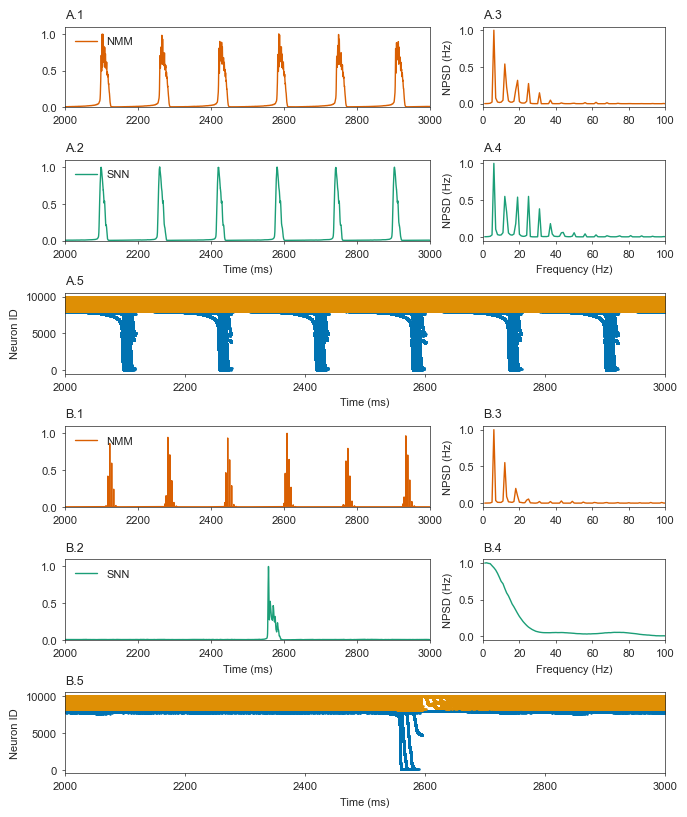

In [30]:
# plotting

fig = plt.figure(figsize=(6.7, 8))
# Define grid: 6 rows, 2 columns
gs = fig.add_gridspec(6,2,figure=fig, width_ratios=[2, 1])

# 2x2 subplots (top)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0], sharex = ax1)
ax4 = fig.add_subplot(gs[1, 1], sharex = ax2)

# Bottom subplot spanning both columns
ax5 = fig.add_subplot(gs[2, :])

# 2x2 subplots (bottom)
ax6 = fig.add_subplot(gs[3, 0])
ax7 = fig.add_subplot(gs[3, 1])
ax8 = fig.add_subplot(gs[4, 0], sharex = ax1)
ax9 = fig.add_subplot(gs[4, 1], sharex = ax2)

# Bottom subplot spanning both columns
ax10 = fig.add_subplot(gs[5, :])

xlim = [2000, 3000]
# plot the closest parameter set examples for 6Hz

ax1.plot(data_MPR_closest_6hz["t"], data_MPR_closest_6hz["y"][0]/np.max(data_MPR_closest_6hz['y'][0, 200000:300000]), label='NMM', color = colors['mpr'])
ax1.set_title('A.1', loc='left')
# ax1.set_xlabel('Time (ms)')
ax1.set_xlim(xlim)
ax1.set_ylim([0, 1.1])
ax1.legend(loc = 'upper left')

ax3.plot(data_SNN_closest_6hz["LFP_exc_t"], data_SNN_closest_6hz["LFP_exc_f"]/np.max(data_SNN_closest_6hz["LFP_exc_f"][200000:300000]), color = colors['snn'], label='SNN')
ax3.set_title('A.2', loc='left')
ax3.set_xlabel('Time (ms)')
ax3.legend(loc = 'upper left')
ax3.set_xlim(xlim)
ax3.set_ylim([0, 1.1])

ax2.plot(freq_mpr_exc_closest_6hz, power_spectrum_mpr_exc_closest_6hz, color=colors['mpr'])
ax4.plot(freq_snn_exc_closest_6hz, power_spectrum_snn_exc_closest_6hz, color=colors['snn'])
ax2.set_title('A.3', loc='left')
ax4.set_title('A.4', loc='left')
ax2.set_ylabel('NPSD (Hz)')
ax4.set_ylabel('NPSD (Hz)')
# ax2.set_xlabel('Frequency (Hz)')
ax4.set_xlabel('Frequency (Hz)')
ax2.set_xlim([0,100])
ax4.set_xlim([0,100])

ax5.scatter(data_SNN_closest_6hz["spike_t_exc"], data_SNN_closest_6hz["spike_ID_exc"], s = 1, color = colors['snn_exc'])
ax5.scatter(data_SNN_closest_6hz["spike_t_inh"], data_SNN_closest_6hz["spike_ID_inh"] + (data_SNN_closest_6hz["N"]*data_SNN_closest_6hz["parameters"]["cp_ee"]), s = 1, color = colors['snn_inh'])
ax5.set_ylabel('Neuron ID')
ax5.set_xlabel('Time (ms)')
ax5.set_title('A.5', loc='left')
ax5.set_xlim(xlim)

# plot the farthest parameter set examples for 6Hz

ax6.plot(data_MPR_farthest_6hz["t"], data_MPR_farthest_6hz["y"][0]/np.max(data_MPR_farthest_6hz['y'][0, 200000:300000]), label='NMM', color = colors['mpr'])
ax6.set_title('B.1', loc='left')
# ax1.set_xlabel('Time (ms)')
ax6.set_xlim(xlim)
ax6.set_ylim([0, 1.1])
ax6.legend(loc = 'upper left')

ax8.plot(data_SNN_farthest_6hz["LFP_exc_t"], data_SNN_farthest_6hz["LFP_exc_f"]/np.max(data_SNN_farthest_6hz["LFP_exc_f"][200000:300000]), color = colors['snn'], label='SNN')
ax8.set_title('B.2', loc='left')
ax8.set_xlabel('Time (ms)')
ax8.legend(loc = 'upper left')
ax8.set_xlim(xlim)
ax8.set_ylim([0, 1.1])

ax7.plot(freq_mpr_exc_farthest_6hz, power_spectrum_mpr_exc_farthest_6hz, color=colors['mpr'])
ax9.plot(freq_snn_exc_farthest_6hz, power_spectrum_snn_exc_farthest_6hz, color=colors['snn'])
ax7.set_title('B.3', loc='left')
ax9.set_title('B.4', loc='left')
ax7.set_ylabel('NPSD (Hz)')
ax9.set_ylabel('NPSD (Hz)')
# ax2.set_xlabel('Frequency (Hz)')
ax9.set_xlabel('Frequency (Hz)')
ax7.set_xlim([0,100])
ax9.set_xlim([0,100])

ax10.scatter(data_SNN_farthest_6hz["spike_t_exc"], data_SNN_farthest_6hz["spike_ID_exc"], s = 1, color = colors['snn_exc'])
ax10.scatter(data_SNN_farthest_6hz["spike_t_inh"], data_SNN_farthest_6hz["spike_ID_inh"] + (data_SNN_farthest_6hz["N"]*data_SNN_farthest_6hz["parameters"]["cp_ee"]), s = 1, color = colors['snn_inh'])
ax10.set_ylabel('Neuron ID')
ax10.set_xlabel('Time (ms)')
ax10.set_title('B.5', loc='left')
ax10.set_xlim(xlim)

fig.tight_layout(pad = 0.1, h_pad=0.1, w_pad=0.1)
fig.savefig('Figures/6hz_trajectory_comparison.png', dpi=300)

In [73]:
# 60Hz examples

# closest parameter set file
parameter_set_name = 'FIGUREDATA/optimized_frequencies'
param_fit_index_closest_60hz = 196 #

mpr_filename_closest_60hz = parameter_set_name + str(param_fit_index_closest_60hz) + '_MPR.pkl'  # Exact path inside the zip
snn_filename_closest_60hz = parameter_set_name + str(param_fit_index_closest_60hz) + '_SNN_Variation_VR_85_VT_85.pkl' # Exact path inside the zip


# farthest parameter set file
parameter_set_name = 'FIGUREDATA/rand_init_optimization_results'
param_fit_index_farthest_60hz = 74

mpr_filename_farthest_60hz = parameter_set_name + str(param_fit_index_farthest_60hz) + '_MPR.pkl'  # Exact path inside the zip
snn_filename_farthest_60hz = parameter_set_name + str(param_fit_index_farthest_60hz) + '_SNN_Variation_VR_85_VT_85.pkl' # Exact path inside the zip



with open(snn_filename_closest_60hz, "rb") as pkl_file:
    data_SNN_closest_60hz = pickle.load(pkl_file)

with open(mpr_filename_closest_60hz, 'rb') as file:
    data_MPR_closest_60hz = pickle.load(file)

with open(snn_filename_farthest_60hz, "rb") as pkl_file:
    data_SNN_farthest_60hz = pickle.load(pkl_file)

with open(mpr_filename_farthest_60hz, 'rb') as file:
    data_MPR_farthest_60hz = pickle.load(file)


freq_mpr_exc_closest_60hz, power_spectrum_mpr_exc_closest_60hz, = fourier_analysis(data_MPR_closest_60hz["y"][0], 0.01, data_SNN_closest_60hz["t_end"])
freq_snn_exc_closest_60hz, power_spectrum_snn_exc_closest_60hz, = fourier_analysis(data_SNN_closest_60hz["LFP_exc_f"], 0.01, data_SNN_closest_60hz["t_end"])

freq_mpr_exc_farthest_60hz, power_spectrum_mpr_exc_farthest_60hz, = fourier_analysis(data_MPR_farthest_60hz["y"][0], 0.01, data_SNN_farthest_60hz["t_end"])
freq_snn_exc_farthest_60hz, power_spectrum_snn_exc_farthest_60hz, = fourier_analysis(data_SNN_farthest_60hz["LFP_exc_f"], 0.01, data_SNN_farthest_60hz["t_end"])


In [74]:
# parameter values for the closest and farthest parameter sets for 6Hz and 60Hz examples
df_60 = pd.read_csv('param_freq_target_60.csv')
print('Closeset\n',df_60[
    (df_60['parameter_set_file'] == 'optimized_frequencies') & 
    (df_60['param_ID'] == param_fit_index_closest_60hz)
][['ep_delta', 'ep_eta', 'ip_delta', 'ip_eta', 'sp_ge', 'sp_gi']])

print('Farthest\n',df_60[
    (df_60['parameter_set_file'] == 'rand_init_optimization_results') & 
    (df_60['param_ID'] == param_fit_index_farthest_60hz)
][['ep_delta', 'ep_eta', 'ip_delta', 'ip_eta', 'sp_ge', 'sp_gi']])

Closeset
     ep_delta    ep_eta  ip_delta    ip_eta     sp_ge      sp_gi
87  0.423249  4.087042  0.173706  8.434698  9.440207  26.266605
Farthest
      ep_delta    ep_eta  ip_delta    ip_eta     sp_ge      sp_gi
116  0.384988  2.462051  0.216202  3.320131  8.573948  26.744426


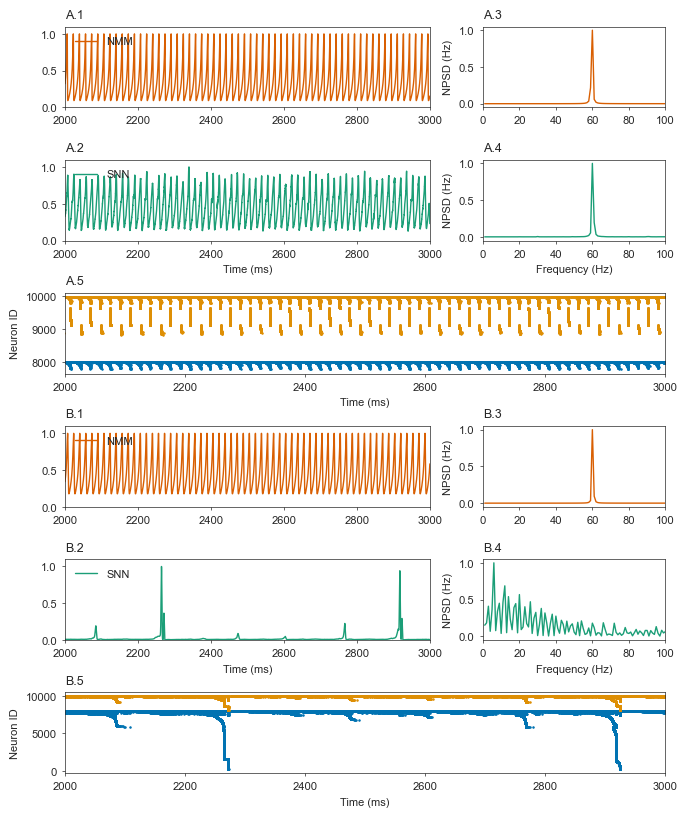

In [29]:
# plotting

fig = plt.figure(figsize=(6.7, 8))
# Define grid: 6 rows, 2 columns
gs = fig.add_gridspec(6,2,figure=fig, width_ratios=[2, 1])

# 2x2 subplots (top)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0], sharex = ax1)
ax4 = fig.add_subplot(gs[1, 1], sharex = ax2)

# Bottom subplot spanning both columns
ax5 = fig.add_subplot(gs[2, :])

# 2x2 subplots (bottom)
ax6 = fig.add_subplot(gs[3, 0])
ax7 = fig.add_subplot(gs[3, 1])
ax8 = fig.add_subplot(gs[4, 0], sharex = ax1)
ax9 = fig.add_subplot(gs[4, 1], sharex = ax2)

# Bottom subplot spanning both columns
ax10 = fig.add_subplot(gs[5, :])

xlim = [2000, 3000]
# plot the closest parameter set examples for 60Hz

ax1.plot(data_MPR_closest_60hz["t"], data_MPR_closest_60hz["y"][0]/np.max(data_MPR_closest_60hz['y'][0, 200000:300000]), label='NMM', color = colors['mpr'])
ax1.set_title('A.1', loc='left')
# ax1.set_xlabel('Time (ms)')
ax1.set_xlim(xlim)
ax1.set_ylim([0, 1.1])
ax1.legend(loc = 'upper left')

ax3.plot(data_SNN_closest_60hz["LFP_exc_t"], data_SNN_closest_60hz["LFP_exc_f"]/np.max(data_SNN_closest_60hz["LFP_exc_f"][200000:300000]), color = colors['snn'], label='SNN')
ax3.set_title('A.2', loc='left')
ax3.set_xlabel('Time (ms)')
ax3.legend(loc = 'upper left')
ax3.set_xlim(xlim)
ax3.set_ylim([0, 1.1])

ax2.plot(freq_mpr_exc_closest_60hz, power_spectrum_mpr_exc_closest_60hz, color=colors['mpr'])
ax4.plot(freq_snn_exc_closest_60hz, power_spectrum_snn_exc_closest_60hz, color=colors['snn'])
ax2.set_title('A.3', loc='left')
ax4.set_title('A.4', loc='left')
ax2.set_ylabel('NPSD (Hz)')
ax4.set_ylabel('NPSD (Hz)')
# ax2.set_xlabel('Frequency (Hz)')
ax4.set_xlabel('Frequency (Hz)')
ax2.set_xlim([0,100])
ax4.set_xlim([0,100])

ax5.scatter(data_SNN_closest_60hz["spike_t_exc"], data_SNN_closest_60hz["spike_ID_exc"], s = 1, color = colors['snn_exc'])
ax5.scatter(data_SNN_closest_60hz["spike_t_inh"], data_SNN_closest_60hz["spike_ID_inh"] + (data_SNN_closest_60hz["N"]*data_SNN_closest_60hz["parameters"]["cp_ee"]), s = 1, color = colors['snn_inh'])
ax5.set_ylabel('Neuron ID')
ax5.set_xlabel('Time (ms)')
ax5.set_title('A.5', loc='left')
ax5.set_xlim(xlim)

# plot the farthest parameter set examples for 60Hz

ax6.plot(data_MPR_farthest_60hz["t"], data_MPR_farthest_60hz["y"][0]/np.max(data_MPR_farthest_60hz['y'][0, 200000:300000]), label='NMM', color = colors['mpr'])
ax6.set_title('B.1', loc='left')
# ax1.set_xlabel('Time (ms)')
ax6.set_xlim(xlim)
ax6.set_ylim([0, 1.1])
ax6.legend(loc = 'upper left')

ax8.plot(data_SNN_farthest_60hz["LFP_exc_t"], data_SNN_farthest_60hz["LFP_exc_f"]/np.max(data_SNN_farthest_60hz["LFP_exc_f"][200000:300000]), color = colors['snn'], label='SNN')
ax8.set_title('B.2', loc='left')
ax8.set_xlabel('Time (ms)')
ax8.legend(loc = 'upper left')
ax8.set_xlim(xlim)
ax8.set_ylim([0, 1.1])

ax7.plot(freq_mpr_exc_farthest_60hz, power_spectrum_mpr_exc_farthest_60hz, color=colors['mpr'])
ax9.plot(freq_snn_exc_farthest_60hz, power_spectrum_snn_exc_farthest_60hz, color=colors['snn'])
ax7.set_title('B.3', loc='left')
ax9.set_title('B.4', loc='left')
ax7.set_ylabel('NPSD (Hz)')
ax9.set_ylabel('NPSD (Hz)')
# ax2.set_xlabel('Frequency (Hz)')
ax9.set_xlabel('Frequency (Hz)')
ax7.set_xlim([0,100])
ax9.set_xlim([0,100])

ax10.scatter(data_SNN_farthest_60hz["spike_t_exc"], data_SNN_farthest_60hz["spike_ID_exc"], s = 1, color = colors['snn_exc'])
ax10.scatter(data_SNN_farthest_60hz["spike_t_inh"], data_SNN_farthest_60hz["spike_ID_inh"] + (data_SNN_farthest_60hz["N"]*data_SNN_farthest_60hz["parameters"]["cp_ee"]), s = 1, color = colors['snn_inh'])
ax10.set_ylabel('Neuron ID')
ax10.set_xlabel('Time (ms)')
ax10.set_title('B.5', loc='left')
ax10.set_xlim(xlim)

fig.tight_layout(pad = 0.1, h_pad=0.1, w_pad=0.1)
fig.savefig('Figures/60hz_trajectory_comparison.png', dpi=300)